 # 02 - Model Training and Experiments

 **Goal:** Train all models (Popularity, KNN, MF, NCF) and generate comparison results.



 This notebook produces the main results table for the research paper.

In [16]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import DataLoader
import time
import os
import sys

# Add src to path
sys.path.insert(0, os.path.abspath('../src'))

from models.baselines import PopularityRecommender, ItemKNNRecommender
from models.mf import MatrixFactorization
from models.ncf import NeuMF
from data_loader import ImplicitFeedbackDataset
from metrics import precision_at_k, recall_at_k, ndcg_at_k

FIGURES_DIR = 'reports/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)


In [17]:
# Load Data
print("Loading data...")
train_df = pd.read_parquet('../data/processed/train.parquet')
val_df = pd.read_parquet('../data/processed/val.parquet')
test_df = pd.read_parquet('../data/processed/test.parquet')

all_df = pd.concat([train_df, val_df, test_df])
unique_users = all_df['reviewerID'].unique()
unique_items = all_df['asin'].unique()

user_map = {u: i for i, u in enumerate(unique_users)}
item_map = {i: idx for idx, i in enumerate(unique_items)}
reverse_item_map = {idx: i for idx, i in enumerate(unique_items)}

n_users = len(user_map)
n_items = len(item_map)

train_df['reviewerID_idx'] = train_df['reviewerID'].map(user_map)
train_df['asin_idx'] = train_df['asin'].map(item_map)

print(f"Users: {n_users}, Items: {n_items}")
print(f"Train: {len(train_df)}, Test: {len(test_df)}")


Loading data...
Users: 368, Items: 282
Train: 1888, Test: 400


 ## Evaluation Function

In [18]:
def evaluate_model(model, test_df, train_df, k_list=[5, 10], is_torch=False, device=None):
    """Evaluate a model on test data."""
    users = test_df['reviewerID'].unique()
    
    # Ground truth
    ground_truth = test_df.groupby('reviewerID')['asin'].apply(set).to_dict()
    seen_items = train_df.groupby('reviewerID')['asin'].apply(set).to_dict()
    
    metrics = {f'P@{k}': [] for k in k_list}
    metrics.update({f'R@{k}': [] for k in k_list})
    metrics.update({f'NDCG@{k}': [] for k in k_list})
    
    for user in users:
        if user not in ground_truth:
            continue
            
        true_items = ground_truth[user]
        seen = seen_items.get(user, set())
        
        max_k = max(k_list)
        
        if is_torch:
            if user not in user_map:
                continue
            u_idx = user_map[user]
            mapped_exclude = [item_map[i] for i in seen if i in item_map]
            rec_indices = model.recommend(u_idx, k=max_k, exclude=mapped_exclude, device=device)
            recs = [reverse_item_map[i] for i in rec_indices]
        else:
            recs = model.recommend(user, k=max_k, exclude=seen)
        
        for k in k_list:
            metrics[f'P@{k}'].append(precision_at_k(recs, true_items, k))
            metrics[f'R@{k}'].append(recall_at_k(recs, true_items, k))
            metrics[f'NDCG@{k}'].append(ndcg_at_k(recs, true_items, k))
    
    return {k: np.mean(v) for k, v in metrics.items()}


 ## 1. Popularity Baseline

In [19]:
print("\n" + "=" * 50)
print("Training Popularity Baseline...")
print("=" * 50)

start = time.time()
pop_model = PopularityRecommender()
pop_model.fit(train_df)
pop_time = time.time() - start

pop_results = evaluate_model(pop_model, test_df, train_df)
pop_results['Time (s)'] = pop_time
print(f"Results: {pop_results}")



Training Popularity Baseline...
Training Popularity Model...
Learned 234 items.
Results: {'P@5': np.float64(0.002285714285714286), 'P@10': np.float64(0.002285714285714286), 'R@5': np.float64(0.004285714285714286), 'R@10': np.float64(0.01), 'NDCG@5': np.float64(0.0028672206935930287), 'NDCG@10': np.float64(0.00502723269586068), 'Time (s)': 0.004663228988647461}


 ## 2. Item-KNN Baseline

In [20]:
print("\n" + "=" * 50)
print("Training Item-KNN (k=20)...")
print("=" * 50)

start = time.time()
knn_model = ItemKNNRecommender(k_neighbors=20)
knn_model.fit(train_df)
knn_time = time.time() - start

knn_results = evaluate_model(knn_model, test_df, train_df)
knn_results['Time (s)'] = knn_time
print(f"Results: {knn_results}")



Training Item-KNN (k=20)...
Training ItemKNN (k=20)...
Computing similarity matrix...
Similarity computed.
Results: {'P@5': np.float64(0.0), 'P@10': np.float64(0.0005714285714285715), 'R@5': np.float64(0.0), 'R@10': np.float64(0.005714285714285714), 'NDCG@5': np.float64(0.0), 'NDCG@10': np.float64(0.0020354696406172696), 'Time (s)': 0.0251467227935791}


 ## 3. Matrix Factorization

In [21]:
print("\n" + "=" * 50)
print("Training Matrix Factorization...")
print("=" * 50)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

mf_model = MatrixFactorization(n_users, n_items, n_factors=32).to(device)
optimizer = torch.optim.Adam(mf_model.parameters(), lr=0.005)
loss_fn = torch.nn.BCEWithLogitsLoss()

dataset = ImplicitFeedbackDataset(train_df, n_users, n_items, num_negatives=4)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

mf_losses = []
start = time.time()

for epoch in range(30):
    mf_model.train()
    total_loss = 0
    for u, i, negs in loader:
        u, i, negs = u.to(device), i.to(device), negs.to(device)
        
        pos_pred = mf_model(u, i)
        loss = loss_fn(pos_pred, torch.ones_like(pos_pred))
        
        for n_idx in range(negs.shape[1]):
            neg_pred = mf_model(u, negs[:, n_idx])
            loss += loss_fn(neg_pred, torch.zeros_like(neg_pred))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    mf_losses.append(total_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/30 - Loss: {total_loss:.4f}")

mf_time = time.time() - start
mf_model.eval()

mf_results = evaluate_model(mf_model, test_df, train_df, is_torch=True, device=device)
mf_results['Time (s)'] = mf_time
print(f"Results: {mf_results}")



Training Matrix Factorization...
Device: cuda
Epoch 10/30 - Loss: 18.3155
Epoch 20/30 - Loss: 14.0362
Epoch 30/30 - Loss: 9.2149
Results: {'P@5': np.float64(0.0), 'P@10': np.float64(0.0017142857142857146), 'R@5': np.float64(0.0), 'R@10': np.float64(0.008571428571428572), 'NDCG@5': np.float64(0.0), 'NDCG@10': np.float64(0.0035838413256864938), 'Time (s)': 2.116128444671631}


 ## 4. Neural Collaborative Filtering (NeuMF)

In [22]:
print("\n" + "=" * 50)
print("Training NeuMF (NCF)...")
print("=" * 50)

ncf_model = NeuMF(n_users, n_items, factor_num=32).to(device)
optimizer = torch.optim.Adam(ncf_model.parameters(), lr=0.001)

ncf_losses = []
start = time.time()

for epoch in range(30):
    ncf_model.train()
    total_loss = 0
    for u, i, negs in loader:
        u, i, negs = u.to(device), i.to(device), negs.to(device)
        
        pos_pred = ncf_model(u, i)
        loss = loss_fn(pos_pred, torch.ones_like(pos_pred))
        
        for n_idx in range(negs.shape[1]):
            neg_pred = ncf_model(u, negs[:, n_idx])
            loss += loss_fn(neg_pred, torch.zeros_like(neg_pred))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    ncf_losses.append(total_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/30 - Loss: {total_loss:.4f}")

ncf_time = time.time() - start
ncf_model.eval()

ncf_results = evaluate_model(ncf_model, test_df, train_df, is_torch=True, device=device)
ncf_results['Time (s)'] = ncf_time
print(f"Results: {ncf_results}")



Training NeuMF (NCF)...
Epoch 10/30 - Loss: 19.2082
Epoch 20/30 - Loss: 17.7718
Epoch 30/30 - Loss: 16.4311
Results: {'P@5': np.float64(0.002285714285714286), 'P@10': np.float64(0.0017142857142857146), 'R@5': np.float64(0.004285714285714286), 'R@10': np.float64(0.007142857142857143), 'NDCG@5': np.float64(0.0033259590413176714), 'NDCG@10': np.float64(0.004380677308629489), 'Time (s)': 2.984052896499634}


 ## Results Summary

In [23]:
import matplotlib.pyplot as plt

# Compile results
results_df = pd.DataFrame({
    'Model': ['Popularity', 'Item-KNN', 'MF', 'NeuMF (NCF)'],
    'P@5': [pop_results['P@5'], knn_results['P@5'], mf_results['P@5'], ncf_results['P@5']],
    'P@10': [pop_results['P@10'], knn_results['P@10'], mf_results['P@10'], ncf_results['P@10']],
    'R@5': [pop_results['R@5'], knn_results['R@5'], mf_results['R@5'], ncf_results['R@5']],
    'R@10': [pop_results['R@10'], knn_results['R@10'], mf_results['R@10'], ncf_results['R@10']],
    'NDCG@5': [pop_results['NDCG@5'], knn_results['NDCG@5'], mf_results['NDCG@5'], ncf_results['NDCG@5']],
    'NDCG@10': [pop_results['NDCG@10'], knn_results['NDCG@10'], mf_results['NDCG@10'], ncf_results['NDCG@10']],
    'Time (s)': [pop_results['Time (s)'], knn_results['Time (s)'], mf_results['Time (s)'], ncf_results['Time (s)']]
})

print("\n" + "=" * 70)
print("FINAL RESULTS TABLE")
print("=" * 70)
print(results_df.to_string(index=False))

# Save to CSV
results_df.to_csv(f'{FIGURES_DIR}/results_table.csv', index=False)
print(f"\nSaved: {FIGURES_DIR}/results_table.csv")



FINAL RESULTS TABLE
      Model      P@5     P@10      R@5     R@10   NDCG@5  NDCG@10  Time (s)
 Popularity 0.002286 0.002286 0.004286 0.010000 0.002867 0.005027  0.004663
   Item-KNN 0.000000 0.000571 0.000000 0.005714 0.000000 0.002035  0.025147
         MF 0.000000 0.001714 0.000000 0.008571 0.000000 0.003584  2.116128
NeuMF (NCF) 0.002286 0.001714 0.004286 0.007143 0.003326 0.004381  2.984053

Saved: reports/figures/results_table.csv


Saved: reports/figures/fig_model_comparison.png


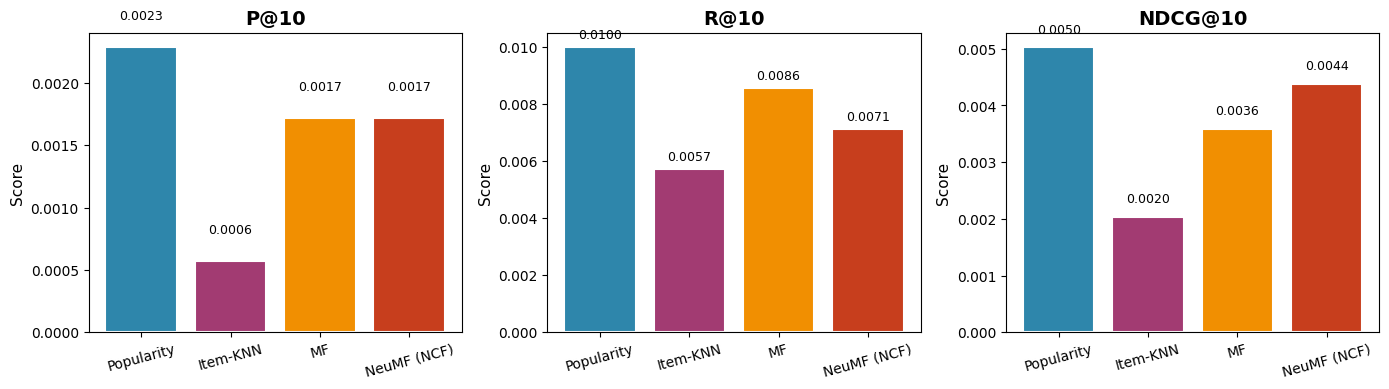

In [24]:
# Model Comparison Bar Chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_to_plot = ['P@10', 'R@10', 'NDCG@10']
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=11)
    ax.tick_params(axis='x', rotation=15)
    
    # Add value labels
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002, 
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_model_comparison.png', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig_model_comparison.pdf', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_model_comparison.png")
plt.show()


Saved: reports/figures/fig_training_loss.png


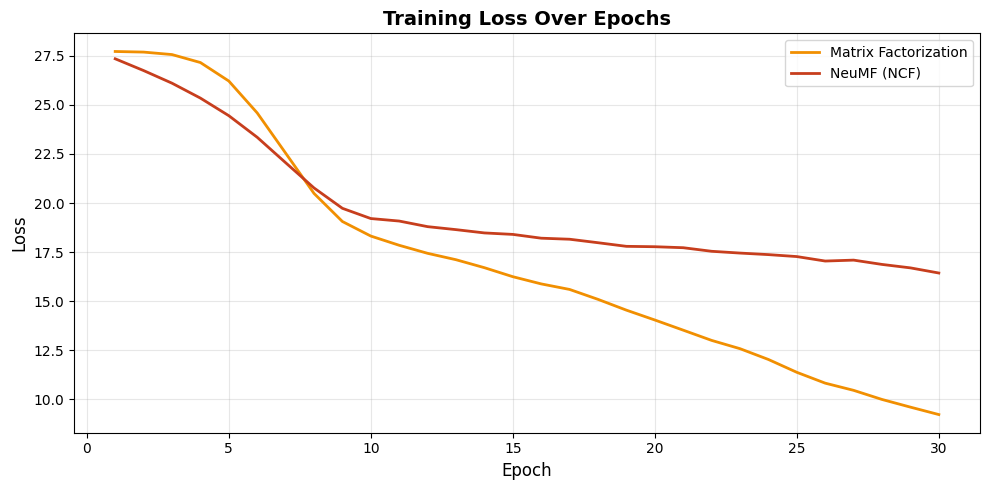


EXPERIMENTS COMPLETE


In [25]:
# Training Loss Curves
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, 31), mf_losses, label='Matrix Factorization', color='#F18F01', linewidth=2)
ax.plot(range(1, 31), ncf_losses, label='NeuMF (NCF)', color='#C73E1D', linewidth=2)
ax.set_title('Training Loss Over Epochs', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig_training_loss.png', bbox_inches='tight')
print(f"Saved: {FIGURES_DIR}/fig_training_loss.png")
plt.show()

print("\n" + "=" * 50)
print("EXPERIMENTS COMPLETE")
print("=" * 50)
